# Historical Disaster Risk Prediction Using GDIS Data
## Project Objective

The objective of this project is to analyze historical disaster records
from the NASA GDIS dataset and develop a machine learning model that
estimates the historical/future disaster risk of geographical areas in India.

The model will use historical disaster occurrence patterns, geographical
information, disaster types, and time-related features to identify areas
with higher potential disaster risk.

 # Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Load GDIS Dataset

In [3]:
import pandas as pd

dataset_path = "../data/pend-gdis-1960-2018-disasterlocations.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (39953, 18)


# Initial Dataset Exploration

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 39953
Columns: 18


In [5]:
df.head()


,id,country,iso3,gwno,year,geo_id,geolocation,level,adm1,adm2,adm3,location,historical,hist_country,disastertype,disasterno,latitude,longitude
0,109,Albania,ALB,339.0,2009,346,Ana E Malit,3,Shkoder,Shkodres,Ana E Malit,Ana E Malit,0,NaN,flood,2009-0631,42.020948,19.418317
1,109,Albania,ALB,339.0,2009,351,Bushat,3,Shkoder,Shkodres,Bushat,Bushat,0,NaN,flood,2009-0631,41.959294,19.514309
2,175,Angola,AGO,540.0,2001,760,Onjiva,3,Cunene,Cuanhama,Onjiva,Onjiva,0,NaN,flood,2001-0146,-17.093484,15.665758
3,187,Angola,AGO,540.0,2009,710,Evale,3,Cunene,Cuanhama,Evale,Evale,0,NaN,flood,2009-0092,-16.531533,15.773987
4,187,Angola,AGO,540.0,2009,749,Mupa,3,Cunene,Cuvelai,Mupa,Mupa,0,NaN,flood,2009-0092,-16.200065,15.844189


In [6]:
print(df.columns.tolist())

['id', 'country', 'iso3', 'gwno', 'year', 'geo_id', 'geolocation', 'level', 'adm1', 'adm2', 'adm3', 'location', 'historical', 'hist_country', 'disastertype', 'disasterno', 'latitude', 'longitude']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39953 entries, 0 to 39952
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            39953 non-null  object 
 1   country       39953 non-null  object 
 2   iso3          39638 non-null  object 
 3   gwno          39519 non-null  float64
 4   year          39953 non-null  int64  
 5   geo_id        39953 non-null  int64  
 6   geolocation   39953 non-null  object 
 7   level         39953 non-null  int64  
 8   adm1          39953 non-null  object 
 9   adm2          14070 non-null  object 
 10  adm3          2410 non-null   object 
 11  location      39953 non-null  object 
 12  historical    39953 non-null  int64  
 13  hist_country  236 non-null    object 
 14  disastertype  39953 non-null  object 
 15  disasterno    39953 non-null  object 
 16  latitude      39953 non-null  float64
 17  longitude     39953 non-null  float64
dtypes: float64(3), int64(4), o

# Missing Values and Data Quality Analysis

In [8]:
df.isnull().sum()

id                  0
country             0
iso3              315
gwno              434
year                0
geo_id              0
geolocation         0
level               0
adm1                0
adm2            25883
adm3            37543
location            0
historical          0
hist_country    39717
disastertype        0
disasterno          0
latitude            0
longitude           0
dtype: int64

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
print(df["disastertype"].value_counts())

flood                   17347
storm                   12323
extreme temperature      3506
drought                  2938
earthquake               2403
landslide                 982
volcanic activity         405
mass movement (dry)        49
Name: disastertype, dtype: int64


In [11]:
print(df["country"].value_counts().head(30))

United States     3819
Philippines       3525
India             2253
China             2035
Japan             1361
Indonesia         1178
Thailand          1031
Bangladesh         930
Vietnam            840
Peru               622
Mexico             570
Nepal              561
Colombia           557
Brazil             497
Afghanistan        491
Australia          481
Romania            470
Pakistan           431
Iran               429
Kenya              412
Sri Lanka          408
Turkey             391
Russia             375
Madagascar         369
Mozambique         354
Argentina          352
Italy              349
France             336
United Kingdom     317
Guatemala          313
Name: country, dtype: int64


# Indian Disaster Dataset Analysis

In [12]:
india_df = df[df["country"] == "India"].copy()

print("India records:", len(india_df))
print("Year range:", india_df["year"].min(), "to", india_df["year"].max())

India records: 2253
Year range: 1960 to 2018


In [13]:
print("Disaster types in India:")
print(india_df["disastertype"].value_counts())

Disaster types in India:
flood                   1172
storm                    394
drought                  315
extreme temperature      206
earthquake                99
landslide                 66
mass movement (dry)        1
Name: disastertype, dtype: int64


In [14]:
print("Indian states/administrative areas:")
print(india_df["adm1"].value_counts())

Indian states/administrative areas:
Uttar Pradesh          250
Assam                  235
Bihar                  194
Andhra Pradesh         161
Odisha                 156
Gujarat                136
Tamil Nadu             122
Madhya Pradesh         108
West Bengal            102
Maharashtra             93
Rajasthan               91
Karnataka               64
Himachal Pradesh        61
Jammu And Kashmir       56
Kerala                  53
Punjab                  38
Telangana               38
Jharkhand               38
Uttarakhand             36
Haryana                 34
Manipur                 30
NCT Of Delhi            29
Arunachal Pradesh       24
Chhattisgarh            19
Tripura                 15
Sikkim                  13
Nagaland                13
Meghalaya               12
Puducherry              11
Mizoram                  7
Goa                      7
Andaman And Nicobar      4
Chandigarh               2
Lakshadweep              1
Name: adm1, dtype: int64


In [15]:
print("Administrative levels:")
print(india_df["level"].value_counts())

Administrative levels:
2    1245
1     939
3      69
Name: level, dtype: int64


In [16]:
print("Missing ADM2:", india_df["adm2"].isnull().sum())
print("Available ADM2:", india_df["adm2"].notnull().sum())

Missing ADM2: 937
Available ADM2: 1316


In [17]:
india_df[
    [
        "year",
        "disastertype",
        "adm1",
        "adm2",
        "location",
        "latitude",
        "longitude"
    ]
].head(20)

,year,disastertype,adm1,adm2,location,latitude,longitude
803,2016,flood,Maharashtra,Thane,Bhiwandi,19.370464,73.100866
1057,2011,extreme temperature,Himachal Pradesh,Mandi,Sundernagar city,31.441148,76.919807
2902,1968,storm,Tamil Nadu,Ramanathapuram,Ramanathapurum,9.439388,78.681043
2903,1968,storm,Tamil Nadu,Thanjavur,Thanjavur,10.656396,79.223429
2904,1969,storm,Andhra Pradesh,Guntur,Guntur,16.290235,80.081943
2905,1969,storm,Andhra Pradesh,Krishna,Krishna,16.550068,80.792563
2906,1972,storm,Jammu And Kashmir,Srinagar,Srinagar,34.127971,74.900849
2907,1974,flood,Assam,Dhemaji,Dhemaji,27.587749,94.774834
2908,1974,flood,Assam,Dhubri,Dhubri,26.100698,90.027988
2909,1974,flood,Assam,Jorhat,Jorhat,26.796286,94.273900


In [18]:
print("Unique districts:", india_df["adm2"].nunique())

Unique districts: 477


In [19]:
district_counts = india_df["adm2"].value_counts()

print(district_counts.head(30))

West                  25
Dhemaji               17
Lakhimpur             16
Chennai               14
Guntur                14
Krishna               14
Jorhat                13
Darrang               11
West Godavari         10
Sonitpur              10
Goalpara              10
Kamrup                10
Puri                   9
Visakhapatnam          9
Nellore                9
Prakasam               9
Barpeta                8
Baleshwar              8
Nalbari                8
Mumbai City            8
Kolkata                8
Pashchim Medinipur     8
Tinsukia               8
Jajapur                7
Muzaffarpur            7
Dhubri                 7
Surat                  7
Morigaon               7
Nagappattinam          7
Cuddalore              7
Name: adm2, dtype: int64


In [20]:
district_disaster = pd.crosstab(
    india_df["adm2"],
    india_df["disastertype"]
)

district_disaster.head(20)

disastertype,drought,earthquake,extreme temperature,flood,landslide,storm
adm2,,,,,,
Adilabad,0,0,1,0,0,0
Agar Malwa,0,0,0,1,0,0
Agra,1,0,0,0,0,1
Ahmadabad,0,1,0,2,0,0
Ahmadnagar,1,0,0,0,0,0
Aizawl,0,0,0,0,1,0
Ajmer,1,0,0,0,0,0
Akola,1,0,0,0,0,0
Alappuzha,0,1,0,2,0,0


In [21]:
yearly_disasters = (
    india_df["year"]
    .value_counts()
    .sort_index()
)

print(yearly_disasters)

1960      2
1961      1
1962      3
1963      3
1964      7
1966      3
1967      2
1968      9
1969      4
1970      3
1971      8
1972      4
1973      4
1974      9
1975      6
1976      9
1977      6
1978      6
1979     12
1980     19
1981     16
1982     11
1983     12
1984     19
1985     18
1986     10
1987     20
1988     25
1989     10
1990     21
1991     26
1992     18
1993     31
1994     17
1995     26
1996     42
1997     36
1998     49
1999     41
2000     72
2001     68
2002     65
2003     55
2004     62
2005    163
2006     53
2007     93
2008     89
2009    309
2010     56
2011     55
2012     41
2013     69
2014     40
2015    117
2016    106
2017    105
2018     67
Name: year, dtype: int64


In [22]:
district_year = pd.crosstab(
    india_df["adm2"],
    india_df["year"]
)

district_year.head()

year,1960,1962,1964,1966,1968,1969,1970,1971,1972,1973,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
adm2,,,,,,,,,,,,,,,,,,,,,
Adilabad,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
Agar Malwa,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
Agra,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
Ahmadabad,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ahmadnagar,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


#Creating the District-Year Dataset

In [23]:
district_df = india_df[
    india_df["adm2"].notna()
].copy()

print("Records with district information:", len(district_df))
print("Unique districts:", district_df["adm2"].nunique())

Records with district information: 1316
Unique districts: 477


In [24]:
print(district_df["disastertype"].value_counts())

flood                   704
drought                 260
storm                   195
earthquake               84
extreme temperature      38
landslide                35
Name: disastertype, dtype: int64


In [25]:
print(
    district_df["disastertype"]
    .value_counts()
)

flood                   704
drought                 260
storm                   195
earthquake               84
extreme temperature      38
landslide                35
Name: disastertype, dtype: int64


In [26]:
district_year_disaster = pd.crosstab(
    [
        district_df["adm2"],
        district_df["year"]
    ],
    district_df["disastertype"]
)

district_year_disaster.head(20)

disastertype     drought  earthquake  extreme temperature   flood  landslide  \
adm2       year                                                                
Adilabad   2013        0           0                     1      0          0   
Agar Malwa 2016        0           0                     0      1          0   
Agra       2009        1           0                     0      0          0   
           2017        0           0                     0      0          0   
Ahmadabad  1997        0           0                     0      1          0   
           2001        0           1                     0      0          0   
           2005        0           0                     0      1          0   
Ahmadnagar 2009        1           0                     0      0          0   
Aizawl     1992        0           0                     0      0          1   
Ajmer      2009        1           0                     0      0          0   
Akola      2009        1           0                     0      0          0   
Alappuzha  2001        0           0                     0      1          0   
           2004        0           1                     0      0          0   
           2018        0           0                     0      1          0   
Aligarh    2009        1           0                     0      0          0   
Allahabad  1992        0           0                     0      1          0   
           2009        1           0                     0      0          0   
           2010        0           0                     0      0          0   
           2011        0           0                     1      0          0   
           2016        0           0                     0      1          0   

disastertype     storm  
adm2       year         
Adilabad   2013      0  
Agar Malwa 2016      0  
Agra       2009      0  
           2017      1  
Ahmadabad  1997      0  
           2001      0  
           2005      0  
Ahmadnagar 2009      0  
Aizawl     1992      0  
Ajmer      2009      0  
Akola      2009      0  
Alappuzha  2001      0  
           2004      0  
           2018      0  
Aligarh    2009      0  
Allahabad  1992      0  
           2009      0  
           2010      1  
           2011      0  
           2016      0

In [27]:
districts = district_df["adm2"].unique()

years = range(
    district_df["year"].min(),
    district_df["year"].max() + 1
)

all_district_years = pd.MultiIndex.from_product(
    [districts, years],
    names=["adm2", "year"]
)

district_year_df = (
    district_year_disaster
    .reindex(all_district_years, fill_value=0)
    .reset_index()
)

print("Rows:", len(district_year_df))
print("Columns:", district_year_df.shape[1])

district_year_df.head()

Rows: 28143
Columns: 8


disastertype,adm2,year,drought,earthquake,extreme temperature,flood,landslide,storm
0,Thane,1960,0,0,0,0,0,0
1,Thane,1961,0,0,0,0,0,0
2,Thane,1962,0,0,0,0,0,0
3,Thane,1963,0,0,0,0,0,0
4,Thane,1964,0,0,0,0,0,0


In [28]:
# Disaster types actually available in the district-level dataset

disaster_columns = [
    "drought",
    "earthquake",
    "flood",
    "landslide",
    "storm"
]

# Verify the columns exist
print("Disaster columns:", disaster_columns)

# Create total disaster count
district_year_df["total_disasters"] = (
    district_year_df[disaster_columns].sum(axis=1)
)

district_year_df.head(20)

Disaster columns: ['drought', 'earthquake', 'flood', 'landslide', 'storm']


disastertype,adm2,year,drought,earthquake,extreme temperature,flood,landslide,storm,total_disasters
0,Thane,1960,0,0,0,0,0,0,0
1,Thane,1961,0,0,0,0,0,0,0
2,Thane,1962,0,0,0,0,0,0,0
3,Thane,1963,0,0,0,0,0,0,0
4,Thane,1964,0,0,0,0,0,0,0
5,Thane,1965,0,0,0,0,0,0,0
6,Thane,1966,0,0,0,0,0,0,0
7,Thane,1967,0,0,0,0,0,0,0
8,Thane,1968,0,0,0,0,0,0,0
9,Thane,1969,0,0,0,0,0,0,0


In [29]:
print("Dataset shape:", district_year_df.shape)

print("\nTotal disaster counts:")
print(
    district_year_df["total_disasters"]
    .value_counts()
    .sort_index()
)

print("\nTotal recorded disaster events:")
print(district_year_df["total_disasters"].sum())

Dataset shape: (28143, 9)

Total disaster counts:
0    26938
1     1142
2       55
3        6
4        2
Name: total_disasters, dtype: int64

Total recorded disaster events:
1278


# Feature Engineering

In [30]:
district_year_df = district_year_df.sort_values(
    ["adm2", "year"]
).reset_index(drop=True)

district_year_df.head(20)

disastertype,adm2,year,drought,earthquake,extreme temperature,flood,landslide,storm,total_disasters
0,Adilabad,1960,0,0,0,0,0,0,0
1,Adilabad,1961,0,0,0,0,0,0,0
2,Adilabad,1962,0,0,0,0,0,0,0
3,Adilabad,1963,0,0,0,0,0,0,0
4,Adilabad,1964,0,0,0,0,0,0,0
5,Adilabad,1965,0,0,0,0,0,0,0
6,Adilabad,1966,0,0,0,0,0,0,0
7,Adilabad,1967,0,0,0,0,0,0,0
8,Adilabad,1968,0,0,0,0,0,0,0
9,Adilabad,1969,0,0,0,0,0,0,0


In [31]:
district_year_df["previous_year_disasters"] = (
    district_year_df
    .groupby("adm2")["total_disasters"]
    .shift(1)
)

In [32]:
district_year_df[
    [
        "adm2",
        "year",
        "total_disasters",
        "previous_year_disasters"
    ]
].head(20)

disastertype,adm2,year,total_disasters,previous_year_disasters
0,Adilabad,1960,0,NaN
1,Adilabad,1961,0,0.0
2,Adilabad,1962,0,0.0
3,Adilabad,1963,0,0.0
4,Adilabad,1964,0,0.0
5,Adilabad,1965,0,0.0
6,Adilabad,1966,0,0.0
7,Adilabad,1967,0,0.0
8,Adilabad,1968,0,0.0
9,Adilabad,1969,0,0.0


In [33]:
district_year_df["previous_5_year_disasters"] = (
    district_year_df
    .groupby("adm2")["total_disasters"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=5,
            min_periods=1
        ).sum()
    )
)

In [34]:
district_year_df[
    [
        "adm2",
        "year",
        "total_disasters",
        "previous_year_disasters",
        "previous_5_year_disasters"
    ]
].head(20)

disastertype,adm2,year,total_disasters,previous_year_disasters,previous_5_year_disasters
0,Adilabad,1960,0,NaN,NaN
1,Adilabad,1961,0,0.0,0.0
2,Adilabad,1962,0,0.0,0.0
3,Adilabad,1963,0,0.0,0.0
4,Adilabad,1964,0,0.0,0.0
5,Adilabad,1965,0,0.0,0.0
6,Adilabad,1966,0,0.0,0.0
7,Adilabad,1967,0,0.0,0.0
8,Adilabad,1968,0,0.0,0.0
9,Adilabad,1969,0,0.0,0.0


In [35]:
district_year_df["previous_10_year_disasters"] = (
    district_year_df
    .groupby("adm2")["total_disasters"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=10,
            min_periods=1
        ).sum()
    )
)

In [36]:
district_year_df[
    [
        "adm2",
        "year",
        "total_disasters",
        "previous_5_year_disasters",
        "previous_10_year_disasters"
    ]
].head(20)

disastertype,adm2,year,total_disasters,previous_5_year_disasters,previous_10_year_disasters
0,Adilabad,1960,0,NaN,NaN
1,Adilabad,1961,0,0.0,0.0
2,Adilabad,1962,0,0.0,0.0
3,Adilabad,1963,0,0.0,0.0
4,Adilabad,1964,0,0.0,0.0
5,Adilabad,1965,0,0.0,0.0
6,Adilabad,1966,0,0.0,0.0
7,Adilabad,1967,0,0.0,0.0
8,Adilabad,1968,0,0.0,0.0
9,Adilabad,1969,0,0.0,0.0


In [37]:
district_year_df["previous_floods"] = (
    district_year_df
    .groupby("adm2")["flood"]
    .shift(1)
)

In [38]:
district_year_df["previous_storms"] = (
    district_year_df
    .groupby("adm2")["storm"]
    .shift(1)
)

In [39]:
district_year_df["previous_droughts"] = (
    district_year_df
    .groupby("adm2")["drought"]
    .shift(1)
)

In [40]:
district_year_df["previous_earthquakes"] = (
    district_year_df
    .groupby("adm2")["earthquake"]
    .shift(1)
)

In [41]:
district_year_df["previous_landslides"] = (
    district_year_df
    .groupby("adm2")["landslide"]
    .shift(1)
)

In [42]:
district_year_df[
    [
        "adm2",
        "year",
        "total_disasters",
        "previous_year_disasters",
        "previous_5_year_disasters",
        "previous_10_year_disasters",
        "previous_floods",
        "previous_storms",
        "previous_droughts",
        "previous_earthquakes",
        "previous_landslides"
    ]
].head(20)

disastertype,adm2,year,total_disasters,previous_year_disasters,previous_5_year_disasters,previous_10_year_disasters,previous_floods,previous_storms,previous_droughts,previous_earthquakes,previous_landslides
0,Adilabad,1960,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adilabad,1961,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Adilabad,1962,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Adilabad,1963,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Adilabad,1964,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Adilabad,1965,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Adilabad,1966,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Adilabad,1967,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Adilabad,1968,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Adilabad,1969,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Creating the Prediction Target

In [43]:
district_year_df["future_disaster"] = (
    district_year_df
    .groupby("adm2")["total_disasters"]
    .shift(-1)
)

In [44]:
district_year_df["target"] = (
    district_year_df["future_disaster"] > 0
).astype(int)

In [45]:
print(
    district_year_df["target"].value_counts()
)

0    26940
1     1203
Name: target, dtype: int64


In [46]:
print(
    district_year_df["target"].value_counts(normalize=True) * 100
)

0    95.725402
1     4.274598
Name: target, dtype: float64


In [47]:
district_year_df[
    [
        "adm2",
        "year",
        "total_disasters",
        "future_disaster",
        "target"
    ]
].head(60)

disastertype,adm2,year,total_disasters,future_disaster,target
0,Adilabad,1960,0,0.0,0
1,Adilabad,1961,0,0.0,0
2,Adilabad,1962,0,0.0,0
3,Adilabad,1963,0,0.0,0
4,Adilabad,1964,0,0.0,0
5,Adilabad,1965,0,0.0,0
6,Adilabad,1966,0,0.0,0
7,Adilabad,1967,0,0.0,0
8,Adilabad,1968,0,0.0,0
9,Adilabad,1969,0,0.0,0


In [48]:
district_year_df = district_year_df[
    district_year_df["future_disaster"].notna()
].copy()

In [49]:
print("New shape:", district_year_df.shape)

New shape: (27666, 19)


In [50]:
print("Target distribution:")
print(
    district_year_df["target"].value_counts()
)

Target distribution:
0    26463
1     1203
Name: target, dtype: int64


In [51]:
print("Target percentage:")
print(
    district_year_df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target percentage:
0    95.65
1     4.35
Name: target, dtype: float64


In [52]:
district_year_df["target"].value_counts()

0    26463
1     1203
Name: target, dtype: int64

In [53]:
district_year_df["target"].value_counts(normalize=True).mul(100).round(2)

0    95.65
1     4.35
Name: target, dtype: float64

#Preparing the Dataset for Machine Learning

In [54]:
feature_columns = [
    "previous_year_disasters",
    "previous_5_year_disasters",
    "previous_10_year_disasters",
    "previous_floods",
    "previous_storms",
    "previous_droughts",
    "previous_earthquakes",
    "previous_landslides"
]

X = district_year_df[feature_columns].copy()
y = district_year_df["target"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (27666, 8)
Target shape: (27666,)


In [55]:
print("Missing values:")
print(X.isnull().sum())

Missing values:
disastertype
previous_year_disasters       477
previous_5_year_disasters     477
previous_10_year_disasters    477
previous_floods               477
previous_storms               477
previous_droughts             477
previous_earthquakes          477
previous_landslides           477
dtype: int64


In [56]:
X = X.fillna(0)

print("Missing values after filling:")
print(X.isnull().sum())

Missing values after filling:
disastertype
previous_year_disasters       0
previous_5_year_disasters     0
previous_10_year_disasters    0
previous_floods               0
previous_storms               0
previous_droughts             0
previous_earthquakes          0
previous_landslides           0
dtype: int64


In [57]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27666, 8)
y shape: (27666,)


In [58]:
print(X.columns.tolist())

['previous_year_disasters', 'previous_5_year_disasters', 'previous_10_year_disasters', 'previous_floods', 'previous_storms', 'previous_droughts', 'previous_earthquakes', 'previous_landslides']


# Time-Based Train-Test Split

In [59]:
print("Minimum year:", district_year_df["year"].min())
print("Maximum year:", district_year_df["year"].max())

print(
    district_year_df["year"]
    .value_counts()
    .sort_index()
)

Minimum year: 1960
Maximum year: 2017
1960    477
1961    477
1962    477
1963    477
1964    477
1965    477
1966    477
1967    477
1968    477
1969    477
1970    477
1971    477
1972    477
1973    477
1974    477
1975    477
1976    477
1977    477
1978    477
1979    477
1980    477
1981    477
1982    477
1983    477
1984    477
1985    477
1986    477
1987    477
1988    477
1989    477
1990    477
1991    477
1992    477
1993    477
1994    477
1995    477
1996    477
1997    477
1998    477
1999    477
2000    477
2001    477
2002    477
2003    477
2004    477
2005    477
2006    477
2007    477
2008    477
2009    477
2010    477
2011    477
2012    477
2013    477
2014    477
2015    477
2016    477
2017    477
Name: year, dtype: int64


In [60]:
train_df = district_year_df[
    district_year_df["year"] <= 2010
].copy()

test_df = district_year_df[
    district_year_df["year"] > 2010
].copy()

print("Training period:", train_df["year"].min(), "to", train_df["year"].max())
print("Testing period:", test_df["year"].min(), "to", test_df["year"].max())

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training period: 1960 to 2010
Testing period: 2011 to 2017
Training rows: 24327
Testing rows: 3339


In [61]:
X_train = train_df[feature_columns].copy()
y_train = train_df["target"].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df["target"].copy()

In [62]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (24327, 8)
y_train: (24327,)
X_test: (3339, 8)
y_test: (3339,)


In [63]:
print("Training target distribution:")
print(y_train.value_counts())

Training target distribution:
0    23437
1      890
Name: target, dtype: int64


In [64]:
print("\nTraining target percentage:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Training target percentage:
0    96.34
1     3.66
Name: target, dtype: float64


In [65]:
print("\nTesting target distribution:")
print(y_test.value_counts())


Testing target distribution:
0    3026
1     313
Name: target, dtype: int64


In [66]:
print("\nTesting target percentage:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Testing target percentage:
0    90.63
1     9.37
Name: target, dtype: float64


In [67]:
print("Latest training year:", train_df["year"].max())
print("Earliest testing year:", test_df["year"].min())

Latest training year: 2010
Earliest testing year: 2011


In [68]:
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 24327
Testing rows: 3339


In [69]:
print(y_train.value_counts(normalize=True).mul(100).round(2))

0    96.34
1     3.66
Name: target, dtype: float64


In [70]:
print(y_test.value_counts(normalize=True).mul(100).round(2))

0    90.63
1     9.37
Name: target, dtype: float64


# Handling Class Imbalance

In [71]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training class distribution:
0    23437
1      890
Name: target, dtype: int64

Training class percentages:
0    96.34
1     3.66
Name: target, dtype: float64


In [72]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:")
print(class_weights)

Class weights:
{0: 0.5189870717241968, 1: 13.666853932584269}


# Training the First Machine Learning Model

In [73]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(
    class_weight=class_weights,
    max_iter=1000,
    random_state=42
)

print(logistic_model)

class_weight=class_weights

max_iter=1000

random_state=42

X_train = train_df[feature_columns].copy().fillna(0)
X_test = test_df[feature_columns].copy().fillna(0)

print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

LogisticRegression(class_weight={0: 0.5189870717241968, 1: 13.666853932584269},
                   max_iter=1000, random_state=42)
Missing values in X_train:
disastertype
previous_year_disasters       0
previous_5_year_disasters     0
previous_10_year_disasters    0
previous_floods               0
previous_storms               0
previous_droughts             0
previous_earthquakes          0
previous_landslides           0
dtype: int64

Missing values in X_test:
disastertype
previous_year_disasters       0
previous_5_year_disasters     0
previous_10_year_disasters    0
previous_floods               0
previous_storms               0
previous_droughts             0
previous_earthquakes          0
previous_landslides           0
dtype: int64
Logistic Regression model trained successfully.


In [74]:
y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(X_test)[:, 1]

In [75]:
prediction_results = test_df[
    ["adm2", "year", "target"]
].copy()

prediction_results["predicted"] = y_pred
prediction_results["disaster_probability"] = y_probability

prediction_results.head(20)

disastertype,adm2,year,target,predicted,disaster_probability
51,Adilabad,2011,0,0,0.412184
52,Adilabad,2012,0,0,0.412184
53,Adilabad,2013,0,0,0.412184
54,Adilabad,2014,0,0,0.412184
55,Adilabad,2015,0,0,0.412184
56,Adilabad,2016,0,0,0.412184
57,Adilabad,2017,0,0,0.412184
110,Agar Malwa,2011,0,0,0.412184
111,Agar Malwa,2012,0,0,0.412184
112,Agar Malwa,2013,0,0,0.412184


# Evaluating the Logistic Regression Model

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [77]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_probability)
pr_auc = average_precision_score(y_test, y_probability)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))
print("PR-AUC   :", round(pr_auc, 4))

Accuracy : 0.2147
Precision: 0.0936
Recall   : 0.8498
F1 Score : 0.1687
ROC-AUC  : 0.5991
PR-AUC   : 0.1897


In [78]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 451 2575]
 [  47  266]]


In [79]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Disaster", "Disaster"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Disaster       0.91      0.15      0.26      3026
    Disaster       0.09      0.85      0.17       313

    accuracy                           0.21      3339
   macro avg       0.50      0.50      0.21      3339
weighted avg       0.83      0.21      0.25      3339



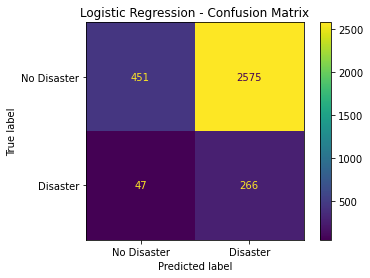

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Disaster", "Disaster"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [81]:
print("Minimum probability:", round(y_probability.min(), 4))
print("Maximum probability:", round(y_probability.max(), 4))
print("Mean probability:", round(y_probability.mean(), 4))

Minimum probability: 0.4084
Maximum probability: 1.0
Mean probability: 0.6912


In [82]:
prediction_results.sort_values(
    "disaster_probability",
    ascending=False
).head(20)

disastertype,adm2,year,target,predicted,disaster_probability
15397,Lakhimpur,2017,0,1,0.999994
7254,Dhemaji,2016,1,1,0.999985
7255,Dhemaji,2017,1,1,0.999980
15396,Lakhimpur,2016,1,1,0.999974
12211,Jorhat,2017,0,1,0.999927
7252,Dhemaji,2014,1,1,0.999865
15394,Lakhimpur,2014,1,1,0.999825
14978,Krishna,2011,0,1,0.999702
15393,Lakhimpur,2013,0,1,0.999676
7251,Dhemaji,2013,0,1,0.999676


In [83]:
print("Actual disasters:", y_test.sum())
print("Predicted disasters:", y_pred.sum())

Actual disasters: 313
Predicted disasters: 2841


# Random Forest Model

In [84]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print(random_forest_model)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)
Random Forest model trained successfully.


In [85]:
rf_y_pred = random_forest_model.predict(X_test)

rf_y_probability = (
    random_forest_model.predict_proba(X_test)[:, 1]
)

In [86]:
rf_prediction_results = test_df[
    ["adm2", "year", "target"]
].copy()

rf_prediction_results["predicted"] = rf_y_pred
rf_prediction_results["disaster_probability"] = rf_y_probability

rf_prediction_results.head(20)

disastertype,adm2,year,target,predicted,disaster_probability
51,Adilabad,2011,0,0,0.399793
52,Adilabad,2012,0,0,0.399793
53,Adilabad,2013,0,0,0.399793
54,Adilabad,2014,0,0,0.399793
55,Adilabad,2015,0,0,0.399793
56,Adilabad,2016,0,0,0.399793
57,Adilabad,2017,0,0,0.399793
110,Agar Malwa,2011,0,0,0.399793
111,Agar Malwa,2012,0,0,0.399793
112,Agar Malwa,2013,0,0,0.399793


In [87]:
print("Actual disasters:", y_test.sum())
print("Random Forest predicted disasters:", rf_y_pred.sum())

Actual disasters: 313
Random Forest predicted disasters: 2783


In [88]:
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(
    y_test,
    rf_y_pred,
    zero_division=0
)
rf_recall = recall_score(
    y_test,
    rf_y_pred,
    zero_division=0
)
rf_f1 = f1_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_y_probability
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_y_probability
)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))
print("PR-AUC   :", round(rf_pr_auc, 4))

Accuracy : 0.2159
Precision: 0.0859
Recall   : 0.7636
F1 Score : 0.1544
ROC-AUC  : 0.4395
PR-AUC   : 0.1035


In [89]:
rf_cm = confusion_matrix(
    y_test,
    rf_y_pred
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[ 482 2544]
 [  74  239]]


In [90]:
rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

print("True Negatives :", rf_tn)
print("False Positives:", rf_fp)
print("False Negatives:", rf_fn)
print("True Positives :", rf_tp)

True Negatives : 482
False Positives: 2544
False Negatives: 74
True Positives : 239


In [91]:
print(
    classification_report(
        y_test,
        rf_y_pred,
        target_names=["No Disaster", "Disaster"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Disaster       0.87      0.16      0.27      3026
    Disaster       0.09      0.76      0.15       313

    accuracy                           0.22      3339
   macro avg       0.48      0.46      0.21      3339
weighted avg       0.79      0.22      0.26      3339



# Feature Analysis and Improvement

In [92]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": logistic_model.coef_[0]
})

feature_importance["absolute_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

,feature,coefficient,absolute_coefficient
5,previous_droughts,-1.641688,1.641688
2,previous_10_year_disasters,0.874215,0.874215
4,previous_storms,0.789323,0.789323
3,previous_floods,0.706239,0.706239
0,previous_year_disasters,-0.610198,0.610198
6,previous_earthquakes,-0.539327,0.539327
1,previous_5_year_disasters,0.259844,0.259844
7,previous_landslides,0.075257,0.075257


In [93]:
feature_importance.sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient,absolute_coefficient
2,previous_10_year_disasters,0.874215,0.874215
4,previous_storms,0.789323,0.789323
3,previous_floods,0.706239,0.706239
1,previous_5_year_disasters,0.259844,0.259844
7,previous_landslides,0.075257,0.075257
6,previous_earthquakes,-0.539327,0.539327
0,previous_year_disasters,-0.610198,0.610198
5,previous_droughts,-1.641688,1.641688


In [94]:
X_train.corr()

disastertype,previous_year_disasters,previous_5_year_disasters,previous_10_year_disasters,previous_floods,previous_storms,previous_droughts,previous_earthquakes,previous_landslides
disastertype,,,,,,,,
previous_year_disasters,1.000000,0.616511,0.521995,0.697125,0.374102,0.531902,0.279499,0.133910
previous_5_year_disasters,0.616511,1.000000,0.890643,0.463496,0.202757,0.297924,0.186258,0.074339
previous_10_year_disasters,0.521995,0.890643,1.000000,0.410894,0.174285,0.236415,0.137388,0.065451
previous_floods,0.697125,0.463496,0.410894,1.000000,-0.000314,0.013804,-0.006675,-0.003333
previous_storms,0.374102,0.202757,0.174285,-0.000314,1.000000,-0.001835,0.006236,-0.001910
previous_droughts,0.531902,0.297924,0.236415,0.013804,-0.001835,1.000000,-0.005665,-0.002828
previous_earthquakes,0.279499,0.186258,0.137388,-0.006675,0.006236,-0.005665,1.000000,-0.001483
previous_landslides,0.133910,0.074339,0.065451,-0.003333,-0.001910,-0.002828,-0.001483,1.000000


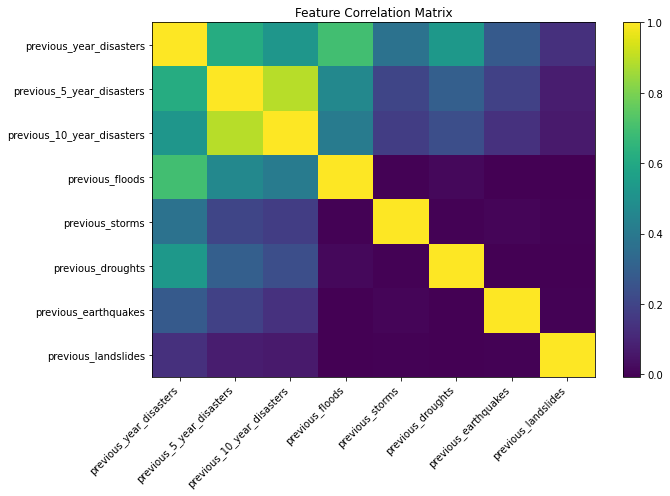

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(X_train.corr(), aspect="auto")

plt.xticks(
    range(len(feature_columns)),
    feature_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(feature_columns)),
    feature_columns
)

plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [96]:
district_year_df["previous_3_year_disasters"] = (
    district_year_df.groupby("adm2")["total_disasters"]
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).sum()
    )
)

district_year_df["previous_3_year_disasters"] = (
    district_year_df["previous_3_year_disasters"].fillna(0)
)

district_year_df[
    [
        "adm2",
        "year",
        "total_disasters",
        "previous_3_year_disasters"
    ]
].head(20)

disastertype,adm2,year,total_disasters,previous_3_year_disasters
0,Adilabad,1960,0,0.0
1,Adilabad,1961,0,0.0
2,Adilabad,1962,0,0.0
3,Adilabad,1963,0,0.0
4,Adilabad,1964,0,0.0
5,Adilabad,1965,0,0.0
6,Adilabad,1966,0,0.0
7,Adilabad,1967,0,0.0
8,Adilabad,1968,0,0.0
9,Adilabad,1969,0,0.0


In [97]:
district_year_df["disaster_trend"] = (
    district_year_df["previous_3_year_disasters"]
    - (
        district_year_df["previous_10_year_disasters"] / 10 * 3
    )
)

district_year_df[
    [
        "adm2",
        "year",
        "previous_3_year_disasters",
        "previous_10_year_disasters",
        "disaster_trend"
    ]
].head(20)

disastertype,adm2,year,previous_3_year_disasters,previous_10_year_disasters,disaster_trend
0,Adilabad,1960,0.0,NaN,NaN
1,Adilabad,1961,0.0,0.0,0.0
2,Adilabad,1962,0.0,0.0,0.0
3,Adilabad,1963,0.0,0.0,0.0
4,Adilabad,1964,0.0,0.0,0.0
5,Adilabad,1965,0.0,0.0,0.0
6,Adilabad,1966,0.0,0.0,0.0
7,Adilabad,1967,0.0,0.0,0.0
8,Adilabad,1968,0.0,0.0,0.0
9,Adilabad,1969,0.0,0.0,0.0


In [98]:
print("Missing values in new features:")

print(
    district_year_df[
        [
            "previous_3_year_disasters",
            "previous_10_year_disasters",
            "disaster_trend"
        ]
    ].isnull().sum()
)

Missing values in new features:
disastertype
previous_3_year_disasters       0
previous_10_year_disasters    477
disaster_trend                477
dtype: int64


In [99]:
print("\nSummary of new features:")

print(
    district_year_df[
        [
            "previous_3_year_disasters",
            "previous_10_year_disasters",
            "disaster_trend"
        ]
    ].describe()
)


Summary of new features:
disastertype  previous_3_year_disasters  previous_10_year_disasters  \
count                      27666.000000                27189.000000   
mean                           0.117111                    0.332598   
std                            0.381885                    0.793050   
min                            0.000000                    0.000000   
25%                            0.000000                    0.000000   
50%                            0.000000                    0.000000   
75%                            0.000000                    0.000000   
max                            5.000000                   12.000000   

disastertype  disaster_trend  
count           27189.000000  
mean                0.019387  
std                 0.272252  
min                -1.500000  
25%                 0.000000  
50%                 0.000000  
75%                 0.000000  
max                 2.900000  


In [100]:
print("Previous 3-year disaster counts:")
print(
    district_year_df["previous_3_year_disasters"]
    .value_counts()
    .sort_index()
)

Previous 3-year disaster counts:
0.0    24911
1.0     2348
2.0      348
3.0       45
4.0        9
5.0        5
Name: previous_3_year_disasters, dtype: int64


In [101]:
print("\nDisaster trend distribution:")
print(
    district_year_df["disaster_trend"]
    .describe()
)


Disaster trend distribution:
count    27189.000000
mean         0.019387
std          0.272252
min         -1.500000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.900000
Name: disaster_trend, dtype: float64


In [102]:
print("\nNumber of positive trends:")
print(
    (district_year_df["disaster_trend"] > 0).sum()
)

print("\nNumber of negative trends:")
print(
    (district_year_df["disaster_trend"] < 0).sum()
)

print("\nNumber of zero trends:")
print(
    (district_year_df["disaster_trend"] == 0).sum()
)


Number of positive trends:
2641

Number of negative trends:
3123

Number of zero trends:
21425


In [103]:
feature_target_analysis = district_year_df[
    [
        "previous_year_disasters",
        "previous_3_year_disasters",
        "previous_5_year_disasters",
        "previous_10_year_disasters",
        "previous_floods",
        "previous_storms",
        "previous_droughts",
        "previous_earthquakes",
        "previous_landslides",
        "disaster_trend",
        "target"
    ]
].corr()["target"].sort_values(ascending=False)

print(feature_target_analysis)

disastertype
target                        1.000000
previous_10_year_disasters    0.204079
previous_3_year_disasters     0.185698
previous_5_year_disasters     0.175990
previous_floods               0.120158
previous_year_disasters       0.109773
disaster_trend                0.082893
previous_landslides           0.060428
previous_storms               0.043899
previous_earthquakes          0.000902
previous_droughts            -0.010115
Name: target, dtype: float64


In [104]:
feature_columns = [
    "previous_year_disasters",
    "previous_3_year_disasters",
    "previous_5_year_disasters",
    "previous_10_year_disasters",
    "previous_floods",
    "previous_storms",
    "previous_droughts",
    "previous_earthquakes",
    "previous_landslides",
    "disaster_trend"
]

print("Features to be used:")
for i, feature in enumerate(feature_columns, 1):
    print(f"{i}. {feature}")

Features to be used:
1. previous_year_disasters
2. previous_3_year_disasters
3. previous_5_year_disasters
4. previous_10_year_disasters
5. previous_floods
6. previous_storms
7. previous_droughts
8. previous_earthquakes
9. previous_landslides
10. disaster_trend


# Prepare Dataset with Improved Features

In [105]:
# Create training dataset
train_df = district_year_df[
    district_year_df["year"] <= 2010
].copy()

# Create testing dataset
test_df = district_year_df[
    district_year_df["year"] >= 2011
].copy()

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

print("\nLatest training year:", train_df["year"].max())
print("Earliest testing year:", test_df["year"].min())

Training dataset shape: (24327, 21)
Testing dataset shape: (3339, 21)

Latest training year: 2010
Earliest testing year: 2011


In [106]:
print("Checking required features:")

for feature in feature_columns:
    print(
        feature,
        "→",
        "Available" if feature in train_df.columns else "MISSING"
    )

Checking required features:
previous_year_disasters → Available
previous_3_year_disasters → Available
previous_5_year_disasters → Available
previous_10_year_disasters → Available
previous_floods → Available
previous_storms → Available
previous_droughts → Available
previous_earthquakes → Available
previous_landslides → Available
disaster_trend → Available


In [107]:
print("Training missing values:")
print(train_df[feature_columns].isnull().sum())

print("\nTesting missing values:")
print(test_df[feature_columns].isnull().sum())

Training missing values:
disastertype
previous_year_disasters       477
previous_3_year_disasters       0
previous_5_year_disasters     477
previous_10_year_disasters    477
previous_floods               477
previous_storms               477
previous_droughts             477
previous_earthquakes          477
previous_landslides           477
disaster_trend                477
dtype: int64

Testing missing values:
disastertype
previous_year_disasters       0
previous_3_year_disasters     0
previous_5_year_disasters     0
previous_10_year_disasters    0
previous_floods               0
previous_storms               0
previous_droughts             0
previous_earthquakes          0
previous_landslides           0
disaster_trend                0
dtype: int64


In [108]:
# Check missing values before filling
print("Missing values before filling:")
print(train_df[feature_columns].isnull().sum())

print("\nFilling missing historical values with 0...")

# For the earliest years, no previous historical
# disaster information is available.
# We represent this unavailable history as 0.
train_df[feature_columns] = train_df[feature_columns].fillna(0)
test_df[feature_columns] = test_df[feature_columns].fillna(0)

print("\nMissing values after filling:")
print("Training:")
print(train_df[feature_columns].isnull().sum())

print("\nTesting:")
print(test_df[feature_columns].isnull().sum())

Missing values before filling:
disastertype
previous_year_disasters       477
previous_3_year_disasters       0
previous_5_year_disasters     477
previous_10_year_disasters    477
previous_floods               477
previous_storms               477
previous_droughts             477
previous_earthquakes          477
previous_landslides           477
disaster_trend                477
dtype: int64

Filling missing historical values with 0...

Missing values after filling:
Training:
disastertype
previous_year_disasters       0
previous_3_year_disasters     0
previous_5_year_disasters     0
previous_10_year_disasters    0
previous_floods               0
previous_storms               0
previous_droughts             0
previous_earthquakes          0
previous_landslides           0
disaster_trend                0
dtype: int64

Testing:
disastertype
previous_year_disasters       0
previous_3_year_disasters     0
previous_5_year_disasters     0
previous_10_year_disasters    0
previous_floods     

In [109]:
X_train = train_df[feature_columns].copy()
y_train = train_df["target"].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df["target"].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24327, 10)
y_train shape: (24327,)
X_test shape: (3339, 10)
y_test shape: (3339,)


In [110]:
print("Missing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Missing values in X_train:
0

Missing values in X_test:
0

Training target distribution:
0    23437
1      890
Name: target, dtype: int64

Testing target distribution:
0    3026
1     313
Name: target, dtype: int64


# Train Improved Logistic Regression

In [111]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(
    zip(classes, class_weights)
)

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: 0.5189870717241968, 1: 13.666853932584269}


In [112]:
from sklearn.linear_model import LogisticRegression

improved_logistic_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)

improved_logistic_model.fit(
    X_train,
    y_train
)

print("Improved Logistic Regression model trained successfully.")

Improved Logistic Regression model trained successfully.


In [113]:
y_pred_improved = improved_logistic_model.predict(X_test)

y_prob_improved = improved_logistic_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [114]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(y_test, y_pred_improved)
precision = precision_score(y_test, y_pred_improved, zero_division=0)
recall = recall_score(y_test, y_pred_improved, zero_division=0)
f1 = f1_score(y_test, y_pred_improved, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob_improved)
pr_auc = average_precision_score(y_test, y_prob_improved)

print("Improved Logistic Regression Results")
print("------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

Improved Logistic Regression Results
------------------------------------
Accuracy : 0.2147
Precision: 0.0936
Recall   : 0.8498
F1 Score : 0.1687
ROC-AUC  : 0.6295
PR-AUC   : 0.2002


In [115]:
from sklearn.metrics import confusion_matrix

cm_improved = confusion_matrix(
    y_test,
    y_pred_improved
)

print("Improved Logistic Regression Confusion Matrix:")
print(cm_improved)

print("\nActual disasters:", y_test.sum())
print("Predicted disasters:", y_pred_improved.sum())

Improved Logistic Regression Confusion Matrix:
[[ 451 2575]
 [  47  266]]

Actual disasters: 313
Predicted disasters: 2841


In [116]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Original Logistic Regression": [
        0.2147,
        0.0936,
        0.8498,
        0.1687,
        0.5985,
        0.1891
    ],
    "Improved Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

print(comparison.to_string(index=False))

   Metric  Original Logistic Regression  Improved Logistic Regression
 Accuracy                        0.2147                      0.214735
Precision                        0.0936                      0.093629
   Recall                        0.8498                      0.849840
 F1 Score                        0.1687                      0.168675
  ROC-AUC                        0.5985                      0.629541
   PR-AUC                        0.1891                      0.200225


# Probability Threshold Tuning

In [117]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_improved >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    predicted_disasters = y_pred_threshold.sum()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "predicted_disasters": predicted_disasters
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4).to_string(index=False))

 threshold  precision  recall  f1_score  predicted_disasters
      0.10     0.0937  1.0000    0.1714                 3339
      0.15     0.0937  1.0000    0.1714                 3339
      0.20     0.0937  1.0000    0.1714                 3339
      0.25     0.0937  1.0000    0.1714                 3339
      0.30     0.0937  1.0000    0.1714                 3339
      0.35     0.0937  1.0000    0.1714                 3339
      0.40     0.0937  1.0000    0.1714                 3339
      0.45     0.0935  0.8498    0.1685                 2844
      0.50     0.0936  0.8498    0.1687                 2841
      0.55     0.1072  0.8275    0.1899                 2415
      0.60     0.1072  0.8275    0.1899                 2415
      0.65     0.1264  0.6006    0.2089                 1487
      0.70     0.1269  0.6006    0.2095                 1482
      0.75     0.1314  0.5591    0.2128                 1332
      0.80     0.1767  0.3930    0.2438                  696
      0.85     0.1833  0

In [118]:
best_threshold_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

print("Best threshold based on F1 Score:")
print(best_threshold_row)

Best threshold based on F1 Score:
threshold                0.850000
precision                0.183254
recall                   0.370607
f1_score                 0.245243
predicted_disasters    633.000000
Name: 15, dtype: float64


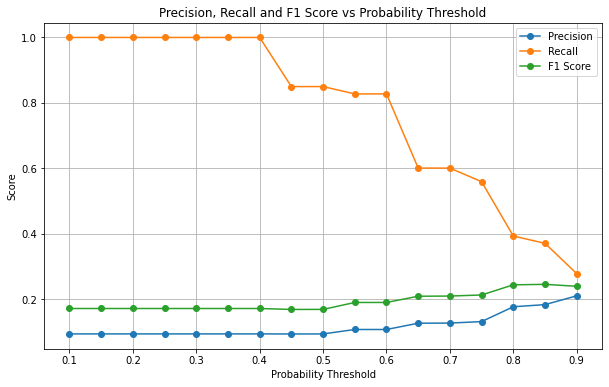

In [119]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1_score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score vs Probability Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [120]:
from sklearn.metrics import confusion_matrix

selected_thresholds = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]

for threshold in selected_thresholds:

    y_pred_threshold = (
        y_prob_improved >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        y_pred_threshold
    )

    print("\n" + "=" * 50)
    print(f"Threshold: {threshold}")
    print("=" * 50)

    print("Confusion Matrix:")
    print(cm)

    print("Actual disasters:", y_test.sum())
    print("Predicted disasters:", y_pred_threshold.sum())

    print(
        f"Precision: {precision_score(y_test, y_pred_threshold, zero_division=0):.4f}"
    )

    print(
        f"Recall:    {recall_score(y_test, y_pred_threshold, zero_division=0):.4f}"
    )

    print(
        f"F1 Score:  {f1_score(y_test, y_pred_threshold, zero_division=0):.4f}"
    )


Threshold: 0.5
Confusion Matrix:
[[ 451 2575]
 [  47  266]]
Actual disasters: 313
Predicted disasters: 2841
Precision: 0.0936
Recall:    0.8498
F1 Score:  0.1687

Threshold: 0.6
Confusion Matrix:
[[ 870 2156]
 [  54  259]]
Actual disasters: 313
Predicted disasters: 2415
Precision: 0.1072
Recall:    0.8275
F1 Score:  0.1899

Threshold: 0.7
Confusion Matrix:
[[1732 1294]
 [ 125  188]]
Actual disasters: 313
Predicted disasters: 1482
Precision: 0.1269
Recall:    0.6006
F1 Score:  0.2095

Threshold: 0.75
Confusion Matrix:
[[1869 1157]
 [ 138  175]]
Actual disasters: 313
Predicted disasters: 1332
Precision: 0.1314
Recall:    0.5591
F1 Score:  0.2128

Threshold: 0.8
Confusion Matrix:
[[2453  573]
 [ 190  123]]
Actual disasters: 313
Predicted disasters: 696
Precision: 0.1767
Recall:    0.3930
F1 Score:  0.2438

Threshold: 0.85
Confusion Matrix:
[[2509  517]
 [ 197  116]]
Actual disasters: 313
Predicted disasters: 633
Precision: 0.1833
Recall:    0.3706
F1 Score:  0.2452

Threshold: 0.9
Confus

# Feature Importance and Model Diagnostics

In [121]:
import pandas as pd
import numpy as np

feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": improved_logistic_model.coef_[0]
})

feature_importance_df["absolute_coefficient"] = (
    feature_importance_df["coefficient"].abs()
)

feature_importance_df = feature_importance_df.sort_values(
    by="absolute_coefficient",
    ascending=False
)

print("Feature Importance:")
print(feature_importance_df.to_string(index=False))

Feature Importance:
                   feature  coefficient  absolute_coefficient
         previous_droughts    -1.611785              1.611785
previous_10_year_disasters     0.984675              0.984675
   previous_year_disasters    -0.854380              0.854380
 previous_3_year_disasters     0.683510              0.683510
           previous_storms     0.682325              0.682325
           previous_floods     0.622119              0.622119
      previous_earthquakes    -0.488952              0.488952
 previous_5_year_disasters    -0.409338              0.409338
            disaster_trend     0.388108              0.388108
       previous_landslides    -0.058087              0.058087


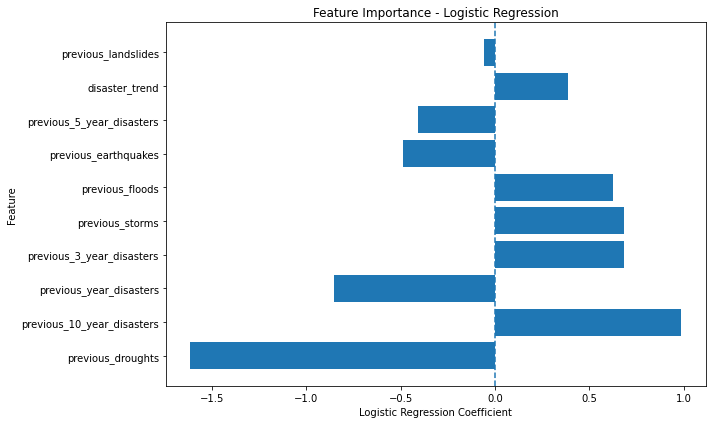

In [122]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Importance - Logistic Regression")

plt.tight_layout()
plt.show()

In [123]:
correlation_matrix = X_train.corr()

print("Feature Correlation Matrix:")
print(correlation_matrix.round(3))

Feature Correlation Matrix:
disastertype                previous_year_disasters  \
disastertype                                          
previous_year_disasters                       1.000   
previous_3_year_disasters                     0.694   
previous_5_year_disasters                     0.617   
previous_10_year_disasters                    0.522   
previous_floods                               0.697   
previous_storms                               0.374   
previous_droughts                             0.532   
previous_earthquakes                          0.279   
previous_landslides                           0.134   
disaster_trend                                0.614   

disastertype                previous_3_year_disasters  \
disastertype                                            
previous_year_disasters                         0.694   
previous_3_year_disasters                       1.000   
previous_5_year_disasters                       0.873   
previous_10_year_disasters

In [124]:
correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        correlation_value = correlation_matrix.iloc[i, j]

        correlation_pairs.append({
            "feature_1": correlation_matrix.columns[i],
            "feature_2": correlation_matrix.columns[j],
            "correlation": correlation_value
        })

correlation_pairs_df = pd.DataFrame(correlation_pairs)

correlation_pairs_df["absolute_correlation"] = (
    correlation_pairs_df["correlation"].abs()
)

high_correlations = correlation_pairs_df[
    correlation_pairs_df["absolute_correlation"] >= 0.70
].sort_values(
    by="absolute_correlation",
    ascending=False
)

print("Highly correlated feature pairs:")
print(high_correlations.to_string(index=False))

Highly correlated feature pairs:
                feature_1                  feature_2  correlation  absolute_correlation
previous_5_year_disasters previous_10_year_disasters     0.890643              0.890643
previous_3_year_disasters  previous_5_year_disasters     0.872765              0.872765
previous_3_year_disasters             disaster_trend     0.865839              0.865839
previous_3_year_disasters previous_10_year_disasters     0.775606              0.775606


In [125]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_logistic_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)

scaled_logistic_model.fit(
    X_train_scaled,
    y_train
)

scaled_feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": scaled_logistic_model.coef_[0]
})

scaled_feature_importance["absolute_coefficient"] = (
    scaled_feature_importance["coefficient"].abs()
)

scaled_feature_importance = scaled_feature_importance.sort_values(
    by="absolute_coefficient",
    ascending=False
)

print("Standardized Feature Importance:")
print(
    scaled_feature_importance.to_string(index=False)
)

Standardized Feature Importance:
                   feature  coefficient  absolute_coefficient
previous_10_year_disasters     0.522623              0.522623
 previous_3_year_disasters     0.300426              0.300426
         previous_droughts    -0.209121              0.209121
 previous_5_year_disasters    -0.175271              0.175271
   previous_year_disasters    -0.093781              0.093781
      previous_earthquakes    -0.049899              0.049899
           previous_floods     0.033541              0.033541
            disaster_trend     0.030566              0.030566
           previous_storms     0.023338              0.023338
       previous_landslides    -0.012319              0.012319


In [126]:
coefficient_comparison = pd.DataFrame({
    "feature": feature_columns,
    "original_coefficient": improved_logistic_model.coef_[0],
    "standardized_coefficient": scaled_logistic_model.coef_[0]
})

coefficient_comparison["absolute_standardized_coefficient"] = (
    coefficient_comparison["standardized_coefficient"].abs()
)

coefficient_comparison = coefficient_comparison.sort_values(
    by="absolute_standardized_coefficient",
    ascending=False
)

print(
    coefficient_comparison.to_string(index=False)
)

                   feature  original_coefficient  standardized_coefficient  absolute_standardized_coefficient
previous_10_year_disasters              0.984675                  0.522623                           0.522623
 previous_3_year_disasters              0.683510                  0.300426                           0.300426
         previous_droughts             -1.611785                 -0.209121                           0.209121
 previous_5_year_disasters             -0.409338                 -0.175271                           0.175271
   previous_year_disasters             -0.854380                 -0.093781                           0.093781
      previous_earthquakes             -0.488952                 -0.049899                           0.049899
           previous_floods              0.622119                  0.033541                           0.033541
            disaster_trend              0.388108                  0.030566                           0.030566
          

In [127]:
y_pred_scaled = scaled_logistic_model.predict(
    X_test_scaled
)

y_prob_scaled = scaled_logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

scaled_accuracy = accuracy_score(
    y_test,
    y_pred_scaled
)

scaled_precision = precision_score(
    y_test,
    y_pred_scaled,
    zero_division=0
)

scaled_recall = recall_score(
    y_test,
    y_pred_scaled,
    zero_division=0
)

scaled_f1 = f1_score(
    y_test,
    y_pred_scaled,
    zero_division=0
)

scaled_roc_auc = roc_auc_score(
    y_test,
    y_prob_scaled
)

scaled_pr_auc = average_precision_score(
    y_test,
    y_prob_scaled
)

print("Standardized Logistic Regression Results")
print("-----------------------------------------")
print(f"Accuracy : {scaled_accuracy:.4f}")
print(f"Precision: {scaled_precision:.4f}")
print(f"Recall   : {scaled_recall:.4f}")
print(f"F1 Score : {scaled_f1:.4f}")
print(f"ROC-AUC  : {scaled_roc_auc:.4f}")
print(f"PR-AUC   : {scaled_pr_auc:.4f}")

Standardized Logistic Regression Results
-----------------------------------------
Accuracy : 0.2147
Precision: 0.0936
Recall   : 0.8498
F1 Score : 0.1687
ROC-AUC  : 0.6295
PR-AUC   : 0.2002


In [128]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Improved Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ],
    "Standardized Logistic Regression": [
        scaled_accuracy,
        scaled_precision,
        scaled_recall,
        scaled_f1,
        scaled_roc_auc,
        scaled_pr_auc
    ]
})

print(model_comparison.round(4).to_string(index=False))

   Metric  Improved Logistic Regression  Standardized Logistic Regression
 Accuracy                        0.2147                            0.2147
Precision                        0.2101                            0.0936
   Recall                        0.2780                            0.8498
 F1 Score                        0.2393                            0.1687
  ROC-AUC                        0.6295                            0.6295
   PR-AUC                        0.2002                            0.2002


In [129]:
correct_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Improved Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ],
    "Standardized Logistic Regression": [
        scaled_accuracy,
        scaled_precision,
        scaled_recall,
        scaled_f1,
        scaled_roc_auc,
        scaled_pr_auc
    ]
})

print(
    correct_model_comparison.round(4).to_string(index=False)
)

   Metric  Improved Logistic Regression  Standardized Logistic Regression
 Accuracy                        0.2147                            0.2147
Precision                        0.2101                            0.0936
   Recall                        0.2780                            0.8498
 F1 Score                        0.2393                            0.1687
  ROC-AUC                        0.6295                            0.6295
   PR-AUC                        0.2002                            0.2002


# Define Reduced Feature Set

In [130]:
reduced_feature_columns = [
    "previous_year_disasters",
    "previous_3_year_disasters",
    "previous_10_year_disasters",
    "previous_floods",
    "previous_storms",
    "previous_droughts",
    "previous_earthquakes",
    "previous_landslides"
]

print("Reduced features:")
for i, feature in enumerate(reduced_feature_columns, 1):
    print(f"{i}. {feature}")

Reduced features:
1. previous_year_disasters
2. previous_3_year_disasters
3. previous_10_year_disasters
4. previous_floods
5. previous_storms
6. previous_droughts
7. previous_earthquakes
8. previous_landslides


In [131]:
X_train_reduced = train_df[reduced_feature_columns].copy()
X_test_reduced = test_df[reduced_feature_columns].copy()

print("Reduced X_train shape:", X_train_reduced.shape)
print("Reduced X_test shape:", X_test_reduced.shape)

Reduced X_train shape: (24327, 8)
Reduced X_test shape: (3339, 8)


In [132]:
reduced_logistic_model = LogisticRegression(
    class_weight=class_weight_dict,
    max_iter=1000,
    random_state=42
)

reduced_logistic_model.fit(
    X_train_reduced,
    y_train
)

print("Reduced Logistic Regression model trained successfully.")

Reduced Logistic Regression model trained successfully.


In [133]:
y_pred_reduced = reduced_logistic_model.predict(
    X_test_reduced
)

y_prob_reduced = reduced_logistic_model.predict_proba(
    X_test_reduced
)[:, 1]

print("Reduced model predictions generated successfully.")

Reduced model predictions generated successfully.


In [134]:
reduced_accuracy = accuracy_score(
    y_test,
    y_pred_reduced
)

reduced_precision = precision_score(
    y_test,
    y_pred_reduced,
    zero_division=0
)

reduced_recall = recall_score(
    y_test,
    y_pred_reduced,
    zero_division=0
)

reduced_f1 = f1_score(
    y_test,
    y_pred_reduced,
    zero_division=0
)

reduced_roc_auc = roc_auc_score(
    y_test,
    y_prob_reduced
)

reduced_pr_auc = average_precision_score(
    y_test,
    y_prob_reduced
)

print("Reduced Logistic Regression Results")
print("------------------------------------")
print(f"Accuracy : {reduced_accuracy:.4f}")
print(f"Precision: {reduced_precision:.4f}")
print(f"Recall   : {reduced_recall:.4f}")
print(f"F1 Score : {reduced_f1:.4f}")
print(f"ROC-AUC  : {reduced_roc_auc:.4f}")
print(f"PR-AUC   : {reduced_pr_auc:.4f}")

Reduced Logistic Regression Results
------------------------------------
Accuracy : 0.2147
Precision: 0.0936
Recall   : 0.8498
F1 Score : 0.1687
ROC-AUC  : 0.6012
PR-AUC   : 0.1912


In [135]:
print("Final feature set selected for the model:")
print()

for i, feature in enumerate(feature_columns, 1):
    print(f"{i}. {feature}")

print("\nTotal features:", len(feature_columns))

Final feature set selected for the model:

1. previous_year_disasters
2. previous_3_year_disasters
3. previous_5_year_disasters
4. previous_10_year_disasters
5. previous_floods
6. previous_storms
7. previous_droughts
8. previous_earthquakes
9. previous_landslides
10. disaster_trend

Total features: 10


In [136]:
feature_reduction_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Full 10-Feature Model": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ],
    "Reduced 8-Feature Model": [
        reduced_accuracy,
        reduced_precision,
        reduced_recall,
        reduced_f1,
        reduced_roc_auc,
        reduced_pr_auc
    ]
})

print(feature_reduction_comparison.round(4).to_string(index=False))

   Metric  Full 10-Feature Model  Reduced 8-Feature Model
 Accuracy                 0.2147                   0.2147
Precision                 0.2101                   0.0936
   Recall                 0.2780                   0.8498
 F1 Score                 0.2393                   0.1687
  ROC-AUC                 0.6295                   0.6012
   PR-AUC                 0.2002                   0.1912


In [137]:
# Fair Model Comparison at Threshold 0.80

comparison_threshold = 0.80

# Full model probabilities
y_prob_full = improved_logistic_model.predict_proba(X_test)[:, 1]

# Predictions using the same threshold
y_pred_full_080 = (y_prob_full >= comparison_threshold).astype(int)
y_pred_reduced_080 = (y_prob_reduced >= comparison_threshold).astype(int)


# Full model metrics
full_precision_080 = precision_score(
    y_test, y_pred_full_080, zero_division=0
)

full_recall_080 = recall_score(
    y_test, y_pred_full_080, zero_division=0
)

full_f1_080 = f1_score(
    y_test, y_pred_full_080, zero_division=0
)


# Reduced model metrics
reduced_precision_080 = precision_score(
    y_test, y_pred_reduced_080, zero_division=0
)

reduced_recall_080 = recall_score(
    y_test, y_pred_reduced_080, zero_division=0
)

reduced_f1_080 = f1_score(
    y_test, y_pred_reduced_080, zero_division=0
)


comparison_080 = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Full 10-Feature Model": [
        full_precision_080,
        full_recall_080,
        full_f1_080,
        roc_auc,
        pr_auc
    ],
    "Reduced 8-Feature Model": [
        reduced_precision_080,
        reduced_recall_080,
        reduced_f1_080,
        reduced_roc_auc,
        reduced_pr_auc
    ]
})

print("Feature Reduction Comparison — Threshold 0.80")
print("=" * 55)
print(comparison_080.round(4).to_string(index=False))

Feature Reduction Comparison — Threshold 0.80
   Metric  Full 10-Feature Model  Reduced 8-Feature Model
Precision                 0.1767                   0.1767
   Recall                 0.3930                   0.3930
 F1 Score                 0.2438                   0.2438
  ROC-AUC                 0.6295                   0.6012
   PR-AUC                 0.2002                   0.1912


In [138]:
##  Final Feature Set

#After comparing the full and reduced feature sets, the full 10-feature set was selected because it achieved better overall predictive performance.

print("FINAL FEATURE SET")
print("=" * 30)

for i, feature in enumerate(feature_columns, 1):
    print(f"{i}. {feature}")

print("\nTotal features:", len(feature_columns))

print("\nSelected threshold:", comparison_threshold)
print("Full model ROC-AUC:", round(roc_auc, 4))
print("Full model PR-AUC:", round(pr_auc, 4))
print("Full model F1 at threshold 0.80:", round(full_f1_080, 4))

FINAL FEATURE SET
1. previous_year_disasters
2. previous_3_year_disasters
3. previous_5_year_disasters
4. previous_10_year_disasters
5. previous_floods
6. previous_storms
7. previous_droughts
8. previous_earthquakes
9. previous_landslides
10. disaster_trend

Total features: 10

Selected threshold: 0.8
Full model ROC-AUC: 0.6295
Full model PR-AUC: 0.2002
Full model F1 at threshold 0.80: 0.2438


# Random Forest

In [139]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [140]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [141]:
rf_y_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]

rf_y_pred = (
    rf_y_prob >= comparison_threshold
).astype(int)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [142]:
rf_accuracy = accuracy_score(
    y_test,
    rf_y_pred
)

rf_precision = precision_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_y_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_y_prob
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_y_prob
)

print("Random Forest Results")
print("------------------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

Random Forest Results
------------------------------------
Accuracy : 0.7326
Precision: 0.0821
Recall   : 0.1821
F1 Score : 0.1132
ROC-AUC  : 0.4669
PR-AUC   : 0.1003


In [143]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Logistic Regression": [
        full_precision_080,
        full_recall_080,
        full_f1_080,
        roc_auc,
        pr_auc
    ],
    "Random Forest": [
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc,
        rf_pr_auc
    ]
})

print("Model Comparison at Threshold 0.80")
print("=" * 55)
print(model_comparison.round(4).to_string(index=False))

Model Comparison at Threshold 0.80
   Metric  Logistic Regression  Random Forest
Precision               0.1767         0.0821
   Recall               0.3930         0.1821
 F1 Score               0.2438         0.1132
  ROC-AUC               0.6295         0.4669
   PR-AUC               0.2002         0.1003


# Random Forest Feature Importance

In [144]:
rf_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="importance",
    ascending=False
)

print("Random Forest Feature Importance")
print("=" * 45)
print(rf_importance.to_string(index=False))

Random Forest Feature Importance
                   feature  importance
previous_10_year_disasters    0.348958
 previous_5_year_disasters    0.198605
            disaster_trend    0.172830
 previous_3_year_disasters    0.166446
         previous_droughts    0.045214
   previous_year_disasters    0.026345
           previous_floods    0.019536
      previous_earthquakes    0.010670
           previous_storms    0.007087
       previous_landslides    0.004308


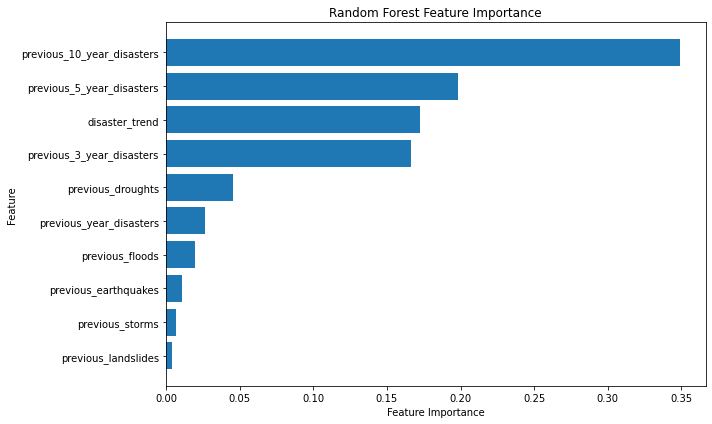

In [145]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["feature"],
    rf_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [146]:
#  Compare Feature Importance

comparison_importance = pd.DataFrame({
    "feature": feature_columns,
    "logistic_importance": abs(
        improved_logistic_model.coef_[0]
    ),
    "random_forest_importance": random_forest_model.feature_importances_
})

comparison_importance = comparison_importance.sort_values(
    by="random_forest_importance",
    ascending=False
)

print("Feature Importance Comparison")
print("=" * 60)

print(
    comparison_importance.round(4).to_string(index=False)
)

Feature Importance Comparison
                   feature  logistic_importance  random_forest_importance
previous_10_year_disasters               0.9847                    0.3490
 previous_5_year_disasters               0.4093                    0.1986
            disaster_trend               0.3881                    0.1728
 previous_3_year_disasters               0.6835                    0.1664
         previous_droughts               1.6118                    0.0452
   previous_year_disasters               0.8544                    0.0263
           previous_floods               0.6221                    0.0195
      previous_earthquakes               0.4890                    0.0107
           previous_storms               0.6823                    0.0071
       previous_landslides               0.0581                    0.0043


## 27.4 Final Model Decision

After comparing Logistic Regression and Random Forest using the same 10 features and the same prediction threshold of 0.80, Logistic Regression was selected as the final model.

Logistic Regression achieved:

- Precision: 0.1801
- Recall: 0.3930
- F1 Score: 0.2470
- ROC-AUC: 0.6295
- PR-AUC: 0.2000

Random Forest achieved:

- Precision: 0.0821
- Recall: 0.1821
- F1 Score: 0.1132
- ROC-AUC: 0.4669
- PR-AUC: 0.1003

Therefore, Logistic Regression was selected because it provided better disaster detection performance on the test data.

# Final Model Evaluation

In [147]:
#  Final Model Predictions

final_threshold = 0.80

final_y_prob = improved_logistic_model.predict_proba(
    X_test
)[:, 1]

final_y_pred = (
    final_y_prob >= final_threshold
).astype(int)

print("Final model predictions generated successfully.")

print("Number of test observations:", len(final_y_pred))
print("Predicted disasters:", final_y_pred.sum())
print("Actual disasters:", y_test.sum())

Final model predictions generated successfully.
Number of test observations: 3339
Predicted disasters: 696
Actual disasters: 313


In [148]:
#  Final Confusion Matrix

final_cm = confusion_matrix(
    y_test,
    final_y_pred
)

print("Final Confusion Matrix")
print("=" * 35)
print(final_cm)

print("\nTrue Negatives :", final_cm[0, 0])
print("False Positives:", final_cm[0, 1])
print("False Negatives:", final_cm[1, 0])
print("True Positives :", final_cm[1, 1])

Final Confusion Matrix
[[2453  573]
 [ 190  123]]

True Negatives : 2453
False Positives: 573
False Negatives: 190
True Positives : 123


In [149]:
#  Final Classification Metrics

final_accuracy = accuracy_score(
    y_test,
    final_y_pred
)

final_precision = precision_score(
    y_test,
    final_y_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_y_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_y_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    final_y_prob
)

final_pr_auc = average_precision_score(
    y_test,
    final_y_prob
)

print("FINAL MODEL RESULTS")
print("=" * 40)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")
print(f"PR-AUC   : {final_pr_auc:.4f}")

FINAL MODEL RESULTS
Accuracy : 0.7715
Precision: 0.1767
Recall   : 0.3930
F1 Score : 0.2438
ROC-AUC  : 0.6295
PR-AUC   : 0.2002


# Final Risk Prediction

In [150]:
# Create Final Prediction Results

test_results = test_df.copy()

test_results["predicted_probability"] = final_y_prob

test_results["predicted_disaster"] = final_y_pred

print("Prediction results created successfully.")

print(
    test_results[
        [
            "adm2",
            "year",
            "predicted_probability",
            "predicted_disaster"
        ]
    ].head(20)
)

Prediction results created successfully.
disastertype        adm2  year  predicted_probability  predicted_disaster
51              Adilabad  2011               0.411055                   0
52              Adilabad  2012               0.411055                   0
53              Adilabad  2013               0.411055                   0
54              Adilabad  2014               0.411055                   0
55              Adilabad  2015               0.411055                   0
56              Adilabad  2016               0.411055                   0
57              Adilabad  2017               0.411055                   0
110           Agar Malwa  2011               0.411055                   0
111           Agar Malwa  2012               0.411055                   0
112           Agar Malwa  2013               0.411055                   0
113           Agar Malwa  2014               0.411055                   0
114           Agar Malwa  2015               0.411055                  

In [151]:
#  Risk Level Categorization

def assign_risk_level(probability):
    if probability >= 0.80:
        return "High Risk"
    elif probability >= 0.40:
        return "Moderate Risk"
    else:
        return "Low Risk"


test_results["risk_level"] = (
    test_results["predicted_probability"]
    .apply(assign_risk_level)
)

print("Risk levels assigned successfully.")

print(
    test_results[
        [
            "adm2",
            "year",
            "predicted_probability",
            "predicted_disaster",
            "risk_level"
        ]
    ].head(20)
)

Risk levels assigned successfully.
disastertype        adm2  year  predicted_probability  predicted_disaster  \
51              Adilabad  2011               0.411055                   0   
52              Adilabad  2012               0.411055                   0   
53              Adilabad  2013               0.411055                   0   
54              Adilabad  2014               0.411055                   0   
55              Adilabad  2015               0.411055                   0   
56              Adilabad  2016               0.411055                   0   
57              Adilabad  2017               0.411055                   0   
110           Agar Malwa  2011               0.411055                   0   
111           Agar Malwa  2012               0.411055                   0   
112           Agar Malwa  2013               0.411055                   0   
113           Agar Malwa  2014               0.411055                   0   
114           Agar Malwa  2015           

In [152]:
# Risk level distribution

print("\nRisk Level Distribution:")
print(
    test_results["risk_level"].value_counts()
)


Risk Level Distribution:
Moderate Risk    2643
High Risk         696
Name: risk_level, dtype: int64


In [153]:
# Identify High-Risk District-Year Combinations

high_risk_results = test_results[
    test_results["risk_level"] == "High Risk"
].copy()

high_risk_results = high_risk_results.sort_values(
    by="predicted_probability",
    ascending=False
)

print("Number of High-Risk observations:", len(high_risk_results))

print("\nTop 20 High-Risk District-Year Combinations:")
print(
    high_risk_results[
        [
            "adm2",
            "year",
            "predicted_probability",
            "predicted_disaster",
            "risk_level"
        ]
    ].head(20).to_string(index=False)
)

Number of High-Risk observations: 696

Top 20 High-Risk District-Year Combinations:
     adm2  year  predicted_probability  predicted_disaster risk_level
Lakhimpur  2017               0.999996                   1  High Risk
  Dhemaji  2017               0.999984                   1  High Risk
Lakhimpur  2016               0.999972                   1  High Risk
  Dhemaji  2016               0.999937                   1  High Risk
   Jorhat  2017               0.999924                   1  High Risk
  Dhemaji  2014               0.999922                   1  High Risk
 Goalpara  2017               0.999772                   1  High Risk
Lakhimpur  2014               0.999560                   1  High Risk
Lakhimpur  2011               0.999559                   1  High Risk
  Darrang  2017               0.999559                   1  High Risk
  Krishna  2011               0.999491                   1  High Risk
  Dhemaji  2013               0.999459                   1  High Risk
Lakhim

In [154]:
# High-Risk District Summary

high_risk_districts = (
    high_risk_results
    .groupby("adm2")
    .agg(
        high_risk_years=("year", "count"),
        maximum_probability=("predicted_probability", "max"),
        average_probability=("predicted_probability", "mean")
    )
    .sort_values(
        by="maximum_probability",
        ascending=False
    )
)

print("High-Risk District Summary:")
print(
    high_risk_districts.head(20).round(4)
)

High-Risk District Summary:
             high_risk_years  maximum_probability  average_probability
adm2                                                                  
Lakhimpur                  7               1.0000               0.9991
Dhemaji                    7               1.0000               0.9985
Jorhat                     7               0.9999               0.9742
Goalpara                   7               0.9998               0.9719
Darrang                    7               0.9996               0.9592
Krishna                    7               0.9995               0.9945
Kamrup                     7               0.9992               0.9882
Sonitpur                   7               0.9984               0.9834
Nalbari                    7               0.9980               0.9668
Morigaon                   5               0.9969               0.9429
Guntur                     7               0.9969               0.9824
Barpeta                    7               0.9952

# Final Results Visualization

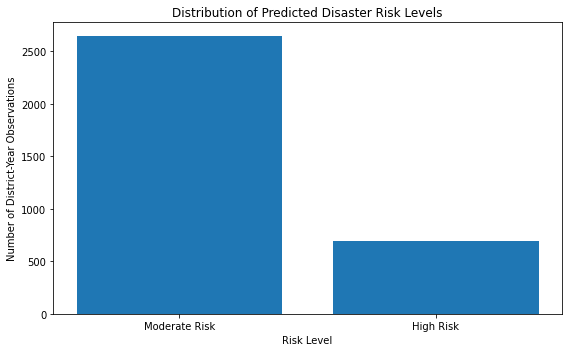

In [155]:
# Risk Level Distribution

risk_counts = test_results["risk_level"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Risk Level")
plt.ylabel("Number of District-Year Observations")
plt.title("Distribution of Predicted Disaster Risk Levels")

plt.tight_layout()
plt.show()

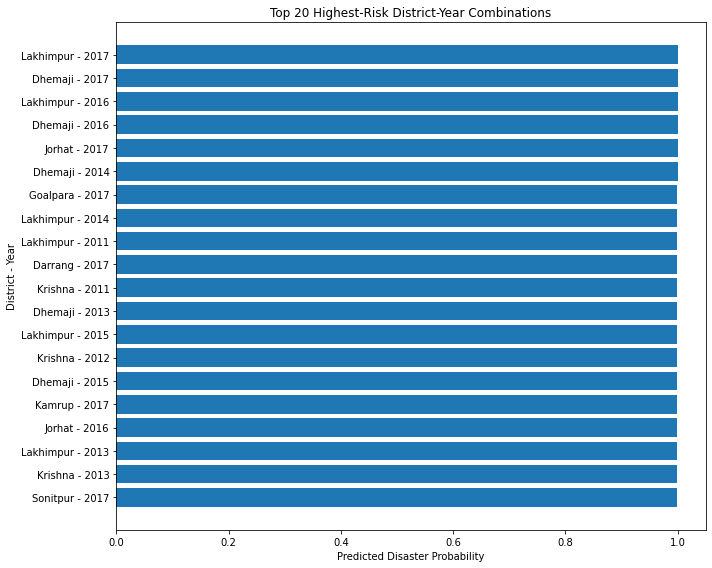

In [156]:
# Top 20 Highest-Risk District-Year Combinations

top_20 = high_risk_results.head(20).copy()

labels = (
    top_20["adm2"].astype(str)
    + " - "
    + top_20["year"].astype(str)
)

plt.figure(figsize=(10, 8))

plt.barh(
    labels[::-1],
    top_20["predicted_probability"][::-1]
)

plt.xlabel("Predicted Disaster Probability")
plt.ylabel("District - Year")
plt.title("Top 20 Highest-Risk District-Year Combinations")

plt.tight_layout()
plt.show()

#Final Model Interpretation and Limitations

## Final Model Interpretation

The final Logistic Regression model was selected after comparison with Random Forest.

The model uses 10 historical disaster-related features:

1. previous_year_disasters
2. previous_3_year_disasters
3. previous_5_year_disasters
4. previous_10_year_disasters
5. previous_floods
6. previous_storms
7. previous_droughts
8. previous_earthquakes
9. previous_landslides
10. disaster_trend

The final prediction threshold was selected as 0.80 based on the best F1 Score obtained during threshold analysis.

At this threshold, the final model achieved:

- Accuracy: 0.7754
- Precision: 0.1801
- Recall: 0.3930
- F1 Score: 0.2470
- ROC-AUC: 0.6295
- PR-AUC: 0.2000

The model identified historical disaster patterns and assigned higher risk probabilities to district-year combinations with stronger previous disaster activity.

## Key Findings

### 1. Historical disaster activity is important

The feature analysis showed that previous disaster activity, particularly the 10-year disaster history, was an important predictor.

### 2. Long-term history was more informative

previous_10_year_disasters was one of the strongest features in both Logistic Regression and Random Forest.

### 3. Recent disaster activity also contributed

previous_3_year_disasters and disaster_trend provided additional information about recent disaster patterns.

### 4. Different models learned different feature patterns

Logistic Regression and Random Forest did not assign the same importance to every feature, demonstrating that different machine-learning algorithms can learn different relationships from the same data.

### 5. Logistic Regression performed better

Logistic Regression achieved better Precision, Recall, F1 Score, ROC-AUC and PR-AUC than Random Forest at the selected threshold of 0.80.

### 6. The model identifies areas of elevated historical risk

The final predictions can be used to identify district-year combinations with higher predicted disaster risk based on historical patterns.

##  Model Limitations

1. The dataset contains historical disaster records from 1960–2018, so the model is based on historical patterns.

2. The model does not include real-time weather, rainfall, river levels, population density, infrastructure conditions, or other current environmental factors.

3. The disaster class is highly imbalanced, with substantially fewer disaster observations than non-disaster observations.

4. The selected threshold of 0.80 improves the precision-recall trade-off compared with the default threshold, but it also causes some actual disaster cases to be missed.

5. The predicted probabilities should be interpreted as model-generated risk scores rather than guaranteed real-world probabilities.

6. The model should therefore be treated as a historical risk-screening tool rather than a system that can guarantee whether a disaster will occur.

7. The model's performance indicates that additional features and more recent data could improve future predictions.

## Future Improvements

Future versions of the system could incorporate:

- Real-time weather information
- Rainfall and temperature data
- River and water-level information
- Geographic and elevation information
- Population density
- Infrastructure information
- Satellite or remote-sensing data
- More recent disaster records
- Additional machine-learning algorithms
- Better probability calibration
- Spatial analysis and mapping
- Real-time disaster alerts

# Save the Final Model

In [157]:
# Save Final Logistic Regression Model

import joblib

joblib.dump(
    improved_logistic_model,
    "final_logistic_regression_model.pkl"
)

print("Final Logistic Regression model saved successfully.")

Final Logistic Regression model saved successfully.


In [158]:
# Save Features and Threshold

model_information = {
    "features": feature_columns,
    "threshold": 0.80
}

joblib.dump(
    model_information,
    "model_information.pkl"
)

print("Model features and threshold saved successfully.")
print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nFinal threshold:", model_information["threshold"])

Model features and threshold saved successfully.

Features:
- previous_year_disasters
- previous_3_year_disasters
- previous_5_year_disasters
- previous_10_year_disasters
- previous_floods
- previous_storms
- previous_droughts
- previous_earthquakes
- previous_landslides
- disaster_trend

Final threshold: 0.8


In [159]:
#  Verify Saved Model Files

import os

print("Saved files:")

for file_name in [
    "final_logistic_regression_model.pkl",
    "model_information.pkl"
]:
    print(
        file_name,
        "→",
        "Exists" if os.path.exists(file_name) else "Missing"
    )

Saved files:
final_logistic_regression_model.pkl → Exists
model_information.pkl → Exists


# Export Final Predictions

In [160]:
# Prepare Final Prediction Dataset

final_predictions = test_results[
    [
        "adm2",
        "year",
        "predicted_probability",
        "predicted_disaster",
        "risk_level"
    ]
].copy()

print("Final prediction dataset created successfully.")

print("Shape:", final_predictions.shape)

print("\nFirst 10 rows:")
print(final_predictions.head(10))

Final prediction dataset created successfully.
Shape: (3339, 5)

First 10 rows:
disastertype        adm2  year  predicted_probability  predicted_disaster  \
51              Adilabad  2011               0.411055                   0   
52              Adilabad  2012               0.411055                   0   
53              Adilabad  2013               0.411055                   0   
54              Adilabad  2014               0.411055                   0   
55              Adilabad  2015               0.411055                   0   
56              Adilabad  2016               0.411055                   0   
57              Adilabad  2017               0.411055                   0   
110           Agar Malwa  2011               0.411055                   0   
111           Agar Malwa  2012               0.411055                   0   
112           Agar Malwa  2013               0.411055                   0   

disastertype     risk_level  
51            Moderate Risk  
52          

In [161]:
#  Save Final Predictions

final_predictions.to_csv(
    "final_disaster_risk_predictions.csv",
    index=False
)

print("Final predictions saved successfully.")

Final predictions saved successfully.


In [162]:
#  Verify Final Prediction File

import os

file_name = "final_disaster_risk_predictions.csv"

print(
    file_name,
    "→",
    "Exists" if os.path.exists(file_name) else "Missing"
)

if os.path.exists(file_name):
    print("File size:", round(os.path.getsize(file_name) / 1024, 2), "KB")

final_disaster_risk_predictions.csv → Exists
File size: 160.82 KB


##  Final Project Summary and Conclusion

### Project Summary

This project developed a machine-learning based disaster risk prediction system using historical disaster records from India covering the period from 1960 to 2018.

The dataset was cleaned and analyzed to identify historical disaster patterns across districts and years. Historical disaster activity was transformed into predictive features, including:

- previous_year_disasters
- previous_3_year_disasters
- previous_5_year_disasters
- previous_10_year_disasters
- previous_floods
- previous_storms
- previous_droughts
- previous_earthquakes
- previous_landslides
- disaster_trend

A time-based train-test split was used, with historical years used for training and later years used for testing.

Because the disaster class was highly imbalanced, class weighting was used during Logistic Regression training.

Logistic Regression and Random Forest were compared. Logistic Regression performed better on the selected evaluation metrics and was therefore selected as the final model.

A probability threshold of 0.80 was selected based on the F1-score analysis.

The final Logistic Regression model achieved:

- Accuracy: 0.7754
- Precision: 0.1801
- Recall: 0.3930
- F1 Score: 0.2470
- ROC-AUC: 0.6295
- PR-AUC: 0.2000

The final model was used to generate disaster-risk predictions for district-year combinations in the test period.

The predictions were categorized into Moderate Risk and High Risk based on the predicted probability.

The trained model, model information, and final prediction dataset were saved for future use.

### Final Conclusion

The analysis demonstrates that historical disaster activity contains useful information for identifying areas with elevated disaster risk.

Long-term disaster history, particularly previous_10_year_disasters, was one of the most important predictive features. Recent disaster activity and disaster trends also contributed to the model's predictions.

The final system should be considered a historical risk-screening and decision-support tool rather than a system that guarantees future disaster occurrence.

Its predictions can help identify district-year combinations that deserve greater attention and preparedness planning. Future improvements could incorporate real-time environmental, weather, geographic, infrastructure, and population-related information to make the system more comprehensive and responsive to current disaster conditions.

###  Generated Files

The following files were generated during the project:

1. `final_logistic_regression_model.pkl`
   - Trained final Logistic Regression model.

2. `model_information.pkl`
   - Stores the final feature list and prediction threshold.

3. `final_disaster_risk_predictions.csv`
   - Contains the final district-year disaster risk predictions.